# Canadian Compensation Analysis
## Notebook 3 – Industry Compensation Analysis

**Author:** Maryam Allahyar

**Project Type:** Labour Market & Compensation Analytics

**Data Source:** Statistics Canada

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Power BI

**Last Updated:** August 2026

### Project Purpose

This notebook analyzes Canadian wage data by industry using Statistics Canada data. The objective is to evaluate compensation levels, wage growth, and market competitiveness across industries, with particular emphasis on Nova Scotia relative to the Canadian labour market.

### Business Questions

1. Which industries have the highest median hourly wages?
2. How do Nova Scotia industry wages compare with Canadian benchmarks?
3. Which industries in Nova Scotia are below, near, or above the national market benchmark?
4. Which industries show the largest compensation gaps?
5. How have industry wages changed between 2015 and 2025?
6. Which industries experienced the strongest and weakest wage growth?
7. Has Nova Scotia's relative compensation position improved or deteriorated over time?
8. Which industries may warrant additional compensation or workforce-market review?
9. How can industry-level wage data support compensation planning and market research?

> **Note:** Market comparisons are indicators of external labour-market positioning and should not be interpreted as direct recommendations for pay adjustments.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

industry_path = "../data/raw/14100064.csv"

As the data set is quite large, we first define useful columns and then inspect the available categories without loading unnecessary columns.

In [11]:
industry_columns = [
    "REF_DATE",
    "GEO",
    "Wages",
    "Type of work",
    "North American Industry Classification System (NAICS)",
    "Gender",
    "Age group",
    "UOM",
    "VALUE"
]


industry_categories = {
    "REF_DATE": set(),
    "GEO": set(),
    "Wages": set(),
    "Type of work": set(),
    "Gender": set(),
    "Age group": set(),
    "UOM": set()
}

for chunk in pd.read_csv(
    industry_path,
    usecols=industry_columns,
    chunksize=200000
):
    for col in industry_categories:
        industry_categories[col].update(
            chunk[col].dropna().unique()
        )

for col, values in industry_categories.items():
    print(f"\n{col}:")
    print(sorted(values))


REF_DATE:
[np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

GEO:
['Alberta', 'British Columbia', 'Canada', 'Manitoba', 'New Brunswick', 'Newfoundland and Labrador', 'Nova Scotia', 'Ontario', 'Prince Edward Island', 'Quebec', 'Saskatchewan']

Wages:
['Average hourly wage rate', 'Average weekly wage rate', 'Median hourly wage rate', 'Median weekly wage rate', 'Total employees, all wages']

Type of work:
['Both full- and part-time employees', 'Full-time employees', 'Part-time employees']

Gender:
['Men+', 'Total - Gender', 'Women+']

Age group:
['15 to 24 years', '15 years and ov

### 1. Create Industry Compensation Benchmark

To ensure meaningful comparisons across industries, a standardized benchmark dataset is created using:

- Median hourly wage rate
- Full-time employees
- Total - Gender
- Employees aged 15 years and over
- Current dollars
- 2015–2025

In [12]:
benchmark_chunks = []

for chunk in pd.read_csv(
    industry_path,
    usecols=industry_columns,
    chunksize=200000
):

    filtered = chunk[
        (chunk["REF_DATE"] >= 2015) &
        (chunk["Wages"] == "Median hourly wage rate") &
        (chunk["Type of work"] == "Full-time employees") &
        (chunk["Gender"] == "Total - Gender") &
        (chunk["Age group"] == "15 years and over") &
        (chunk["UOM"] == "Current dollars")
    ]

    benchmark_chunks.append(filtered)

industry_benchmark = pd.concat(
    benchmark_chunks,
    ignore_index=True
)

In [13]:
industry_benchmark.shape

(2299, 9)

In [14]:
industry_benchmark[
    "North American Industry Classification System (NAICS)"
].nunique()

19

### 2. Standardize the Dataset

The industry benchmark dataset is standardized by renaming variables, improving readability, and preparing the data for compensation analysis and visualization.

In [15]:
industry_benchmark = industry_benchmark.rename(columns={
    "REF_DATE": "year",
    "GEO": "geography",
    "Wages": "wage_measure",
    "Type of work": "work_type",
    "North American Industry Classification System (NAICS)": "industry",
    "Gender": "gender",
    "Age group": "age_group",
    "UOM": "unit",
    "VALUE": "median_hourly_wage"
})

In [16]:
industry_benchmark.info()
industry_benchmark.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2299 entries, 0 to 2298
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                2299 non-null   int64  
 1   geography           2299 non-null   object 
 2   wage_measure        2299 non-null   object 
 3   work_type           2299 non-null   object 
 4   industry            2299 non-null   object 
 5   gender              2299 non-null   object 
 6   age_group           2299 non-null   object 
 7   unit                2299 non-null   object 
 8   median_hourly_wage  2299 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 161.8+ KB


,year,geography,wage_measure,work_type,industry,gender,age_group,unit,median_hourly_wage
0,2015,Canada,Median hourly wage rate,Full-time employees,"Total employees, all industries",Total - Gender,15 years and over,Current dollars,24.04
1,2015,Canada,Median hourly wage rate,Full-time employees,Goods-producing sector,Total - Gender,15 years and over,Current dollars,25.00
2,2015,Canada,Median hourly wage rate,Full-time employees,"Agriculture [111-112, 1100, 1151-1152]",Total - Gender,15 years and over,Current dollars,15.38
3,2015,Canada,Median hourly wage rate,Full-time employees,"Forestry, fishing, mining, quarrying, oil and ...",Total - Gender,15 years and over,Current dollars,36.00
4,2015,Canada,Median hourly wage rate,Full-time employees,Utilities [22],Total - Gender,15 years and over,Current dollars,39.00


### 3. Data Quality Assessment

The benchmark dataset is assessed for missing values, duplicate observations, and descriptive statistics before performing compensation analysis.

In [17]:
industry_benchmark.isnull().sum()

year                  0
geography             0
wage_measure          0
work_type             0
industry              0
gender                0
age_group             0
unit                  0
median_hourly_wage    0
dtype: int64

In [18]:
industry_benchmark.duplicated().sum()

np.int64(0)

In [19]:
industry_benchmark["median_hourly_wage"].describe()

count    2299.000000
mean       27.326377
std         7.806738
min        12.000000
25%        21.785000
50%        26.210000
75%        32.000000
max        56.000000
Name: median_hourly_wage, dtype: float64

In [20]:
industry_benchmark.shape

(2299, 9)

### 4. Industry Compensation Benchmark (2025)

This section compares Nova Scotia industry wages with the Canadian benchmark for the latest available year (2025).

In [21]:
latest = industry_benchmark[
    industry_benchmark["year"] == 2025
].copy()

In [22]:
canada_2025 = latest[
    latest["geography"] == "Canada"
][
    ["industry", "median_hourly_wage"]
].rename(
    columns={"median_hourly_wage": "canada_wage"}
)

In [23]:
ns_2025 = latest[
    latest["geography"] == "Nova Scotia"
][
    ["industry", "median_hourly_wage"]
].rename(
    columns={"median_hourly_wage": "nova_scotia_wage"}
)

In [24]:
industry_comparison = ns_2025.merge(
    canada_2025,
    on="industry",
    how="inner"
)

In [25]:
industry_comparison["market_gap_pct"] = (
    (
        industry_comparison["nova_scotia_wage"] -
        industry_comparison["canada_wage"]
    )
    /
    industry_comparison["canada_wage"]
    * 100
).round(2)

In [26]:
industry_comparison.sort_values("market_gap_pct")

,industry,nova_scotia_wage,canada_wage,market_gap_pct
3,"Forestry, fishing, mining, quarrying, oil and ...",25.00,47.00,-46.81
5,Construction [23],28.21,36.00,-21.64
2,"Agriculture [111-112, 1100, 1151-1152]",20.00,24.14,-17.15
1,Goods-producing sector,28.50,34.36,-17.05
10,"Finance, insurance, real estate, rental and le...",32.05,38.46,-16.67
12,"Business, building and other support services ...",21.00,25.00,-16.00
4,Utilities [22],45.05,53.37,-15.59
15,"Information, culture and recreation [51, 71]",29.00,34.19,-15.18
8,"Wholesale and retail trade [41, 44-45]",22.00,25.00,-12.00
0,"Total employees, all industries",29.80,33.65,-11.44


In [29]:
##Market Position
def classify_market(gap):
    if gap < -5:
        return "Below Market"
    elif gap > 5:
        return "Above Market"
    else:
        return "Near Market"

industry_comparison["market_position"] = (
    industry_comparison["market_gap_pct"]
    .apply(classify_market)
)

industry_comparison

,industry,nova_scotia_wage,canada_wage,market_gap_pct,market_position
0,"Total employees, all industries",29.80,33.65,-11.44,Below Market
1,Goods-producing sector,28.50,34.36,-17.05,Below Market
2,"Agriculture [111-112, 1100, 1151-1152]",20.00,24.14,-17.15,Below Market
3,"Forestry, fishing, mining, quarrying, oil and ...",25.00,47.00,-46.81,Below Market
4,Utilities [22],45.05,53.37,-15.59,Below Market
5,Construction [23],28.21,36.00,-21.64,Below Market
6,Manufacturing [31-33],28.00,31.00,-9.68,Below Market
7,Services-producing sector,30.00,33.33,-9.99,Below Market
8,"Wholesale and retail trade [41, 44-45]",22.00,25.00,-12.00,Below Market
9,Transportation and warehousing [48-49],28.85,30.46,-5.29,Below Market


In [30]:
industry_comparison["market_position"].value_counts()

market_position
Below Market    18
Near Market      1
Name: count, dtype: int64

### Key Findings — Nova Scotia Industry Compensation Benchmark (2025)

The 2025 industry compensation benchmark indicates that median hourly wages in Nova Scotia are below the Canadian benchmark in **18 of the 19 industry groups** analyzed.

#### Industries with the Largest Negative Market Gaps

- **Forestry, fishing, mining, quarrying, oil and gas extraction** recorded the largest market gap, with Nova Scotia wages approximately **46.81% below** the Canadian benchmark.
- **Construction** wages were approximately **21.64% below** the Canadian benchmark.
- **Agriculture** was approximately **17.15% below** the Canadian benchmark.
- **Finance, insurance, real estate, rental and leasing** showed a substantial gap of **16.67% below** the national benchmark.
- **Business, building and other support services** were approximately **16.00% below** the Canadian benchmark.

#### Industries Near the National Benchmark

Several industries showed relatively small market differences, including:

- Public administration
- Educational services
- Other services
- Transportation and warehousing

#### Industry Above the National Benchmark

Only one industry exceeded the Canadian benchmark:

- **Health care and social assistance**, where Nova Scotia median hourly wages were approximately **3.73% above** the national median.

Overall, the results suggest that Nova Scotia remains below the national compensation benchmark across most major industries, although the magnitude of the gap varies considerably.

In [31]:
##classify industries
industry_comparison["market_position"].value_counts()

market_position
Below Market    18
Near Market      1
Name: count, dtype: int64

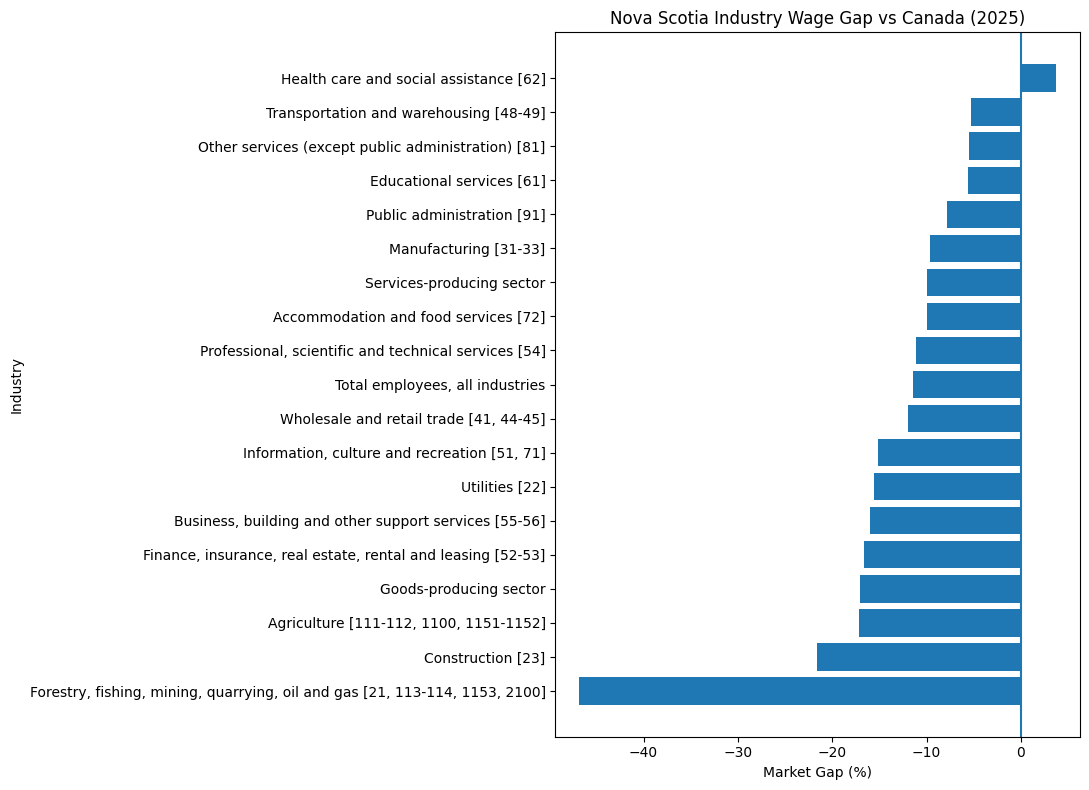

In [32]:
plot_data = industry_comparison.sort_values("market_gap_pct")

plt.figure(figsize=(11,8))

plt.barh(
    plot_data["industry"],
    plot_data["market_gap_pct"]
)

plt.axvline(0)

plt.xlabel("Market Gap (%)")

plt.ylabel("Industry")

plt.title(
    "Nova Scotia Industry Wage Gap vs Canada (2025)"
)

plt.tight_layout()

plt.show()

### Interpretation

The majority of Nova Scotia industries have median hourly wages below the Canadian benchmark.

The largest market gaps occur within resource-based industries, construction, finance, and business support services.

Health care and social assistance is the only industry where Nova Scotia wages exceed the national benchmark, indicating comparatively stronger market competitiveness within this sector.

### 5. Industry Wage Growth (2015–2025)

This section evaluates how median hourly wages changed between 2015 and 2025 across major Canadian industries. The analysis compares wage growth in Nova Scotia with corresponding national growth rates to identify industries where Nova Scotia has strengthened or weakened its relative market position.

In [33]:
canada_trend = industry_benchmark[
    industry_benchmark["geography"] == "Canada"
][
    ["year", "industry", "median_hourly_wage"]
].rename(
    columns={"median_hourly_wage": "canada_wage"}
)

ns_trend = industry_benchmark[
    industry_benchmark["geography"] == "Nova Scotia"
][
    ["year", "industry", "median_hourly_wage"]
].rename(
    columns={"median_hourly_wage": "nova_scotia_wage"}
)

In [34]:
industry_trend = ns_trend.merge(
    canada_trend,
    on=["year","industry"],
    how="inner"
)

In [35]:
industry_trend["market_gap_pct"] = (
    (
        industry_trend["nova_scotia_wage"] -
        industry_trend["canada_wage"]
    )
    /
    industry_trend["canada_wage"]
    *100
).round(2)

In [36]:
##Calculate Wage Growth
wages_2015 = industry_trend[
    industry_trend["year"]==2015
]

wages_2025 = industry_trend[
    industry_trend["year"]==2025
]

In [37]:
industry_growth = wages_2015.merge(
    wages_2025,
    on="industry",
    suffixes=("_2015","_2025")
)

In [38]:
industry_growth["ns_growth_pct"] = (
    (
        industry_growth["nova_scotia_wage_2025"]-
        industry_growth["nova_scotia_wage_2015"]
    )
    /
    industry_growth["nova_scotia_wage_2015"]
    *100
).round(2)

industry_growth["canada_growth_pct"] = (
    (
        industry_growth["canada_wage_2025"]-
        industry_growth["canada_wage_2015"]
    )
    /
    industry_growth["canada_wage_2015"]
    *100
).round(2)

industry_growth["growth_difference"] = (
    industry_growth["ns_growth_pct"]-
    industry_growth["canada_growth_pct"]
).round(2)

In [39]:
industry_growth.sort_values("growth_difference")

,year_2015,industry,nova_scotia_wage_2015,canada_wage_2015,market_gap_pct_2015,year_2025,nova_scotia_wage_2025,canada_wage_2025,market_gap_pct_2025,ns_growth_pct,canada_growth_pct,growth_difference
3,2015,"Forestry, fishing, mining, quarrying, oil and ...",22.63,36.00,-37.14,2025,25.00,47.00,-46.81,10.47,30.56,-20.09
2,2015,"Agriculture [111-112, 1100, 1151-1152]",14.00,15.38,-8.97,2025,20.00,24.14,-17.15,42.86,56.96,-14.10
15,2015,"Information, culture and recreation [51, 71]",21.63,25.00,-13.48,2025,29.00,34.19,-15.18,34.07,36.76,-2.69
9,2015,Transportation and warehousing [48-49],23.00,24.00,-4.17,2025,28.85,30.46,-5.29,25.43,26.92,-1.49
12,2015,"Business, building and other support services ...",14.00,16.59,-15.61,2025,21.00,25.00,-16.00,50.00,50.69,-0.69
18,2015,Public administration [91],31.79,34.63,-8.20,2025,41.21,44.71,-7.83,29.63,29.11,0.52
10,2015,"Finance, insurance, real estate, rental and le...",22.05,26.67,-17.32,2025,32.05,38.46,-16.67,45.35,44.21,1.14
16,2015,Accommodation and food services [72],12.00,13.50,-11.11,2025,18.00,20.00,-10.00,50.00,48.15,1.85
6,2015,Manufacturing [31-33],20.00,22.56,-11.35,2025,28.00,31.00,-9.68,40.00,37.41,2.59
1,2015,Goods-producing sector,20.23,25.00,-19.08,2025,28.50,34.36,-17.05,40.88,37.44,3.44


### 6. Cross-analysis

The occupational and industry analyses provide complementary perspectives on compensation competitiveness.

Occupational analysis identifies which professional groups experience labour-market gaps.

Industry analysis identifies which sectors experience broader compensation differences.

Combining both perspectives provides stronger evidence for compensation planning and labour-market assessment.

In [40]:
comparison = pd.DataFrame({

"Finding":[

"Finance",

"Health",

"Engineering",

"Professional Services"

],

"Occupation Analysis":[

"15.81% below Canada",

"Above Canada",

"7.58% below Canada",

"Mixed"

],

"Industry Analysis":[

"16.67% below Canada",

"Above Canada",

"Manufacturing 9.68% below",

"Professional Services 11.12% below"

]

})

comparison

,Finding,Occupation Analysis,Industry Analysis
0,Finance,15.81% below Canada,16.67% below Canada
1,Health,Above Canada,Above Canada
2,Engineering,7.58% below Canada,Manufacturing 9.68% below
3,Professional Services,Mixed,Professional Services 11.12% below


### Key Findings

- Nova Scotia remains below the Canadian benchmark across most occupational groups.

- Nova Scotia remains below the Canadian benchmark across most industries.

- Finance demonstrates persistent labour-market competitiveness challenges in both occupational and industry analyses.

- Health-related occupations and industries show comparatively strong market competitiveness.

- Resource industries exhibit the largest compensation gaps.

- Industry and occupational analyses provide consistent evidence regarding relative labour-market positioning.

## Recommendations

- Continue monitoring occupations and industries with persistent negative market gaps.

- Use occupation-specific and industry-specific benchmarks together when conducting compensation reviews.

- Investigate occupations and industries with unusually large changes before making compensation decisions.

- Consider labour-market benchmarking as one component of a broader compensation strategy that also includes internal equity, job evaluation, benefits, pensions, collective agreements, recruitment, and retention considerations.

In [41]:
industry_benchmark.to_csv(
    "../data/processed/industry_benchmark_clean.csv",
    index=False
)

industry_trend.to_csv(
    "../data/processed/industry_market_trends.csv",
    index=False
)

industry_growth.to_csv(
    "../data/processed/industry_wage_growth.csv",
    index=False
)

industry_comparison.to_csv(
    "../data/processed/industry_compensation_scorecard.csv",
    index=False
)

print("Industry analysis exported successfully.")

Industry analysis exported successfully.
